In [2]:
!git clone https://github.com/G-mikael/DL_PA2.git

Cloning into 'DL_PA2'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 35 (delta 2), reused 31 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 545.52 KiB | 17.05 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
%cd DL_PA2/

/content/DL_PA2


In [4]:
# Para baixar o dataset completo (5.5GB)
# !python data/download_data.py --full

# Para testes rápidos iniciais (apenas 10MB)
!python data/download_data.py

🚀 Preparando o pacote LEVE de anotações/detecções (~10 MB)...
⬇️ Baixando https://motchallenge.net/data/MOT17Labels.zip...
✅ Download concluído!
📦 Extraindo MOT17Labels.zip em /content/DL_PA2/data/MOT17...
✅ Extração concluída com sucesso!


In [5]:
# @title
import os

folder_path = 'data/MOT17'

print(f"Tamanhos dos arquivos e pastas em '{folder_path}':")

def get_dir_size(start_path='.'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(start_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isfile(item_path):
        file_size = os.path.getsize(item_path) # size in bytes
        print(f"  Arquivo: {item}: {file_size / (1024 * 1024):.2f} MB ({file_size / (1024 * 1024 * 1024):.2f} GB)")
    elif os.path.isdir(item_path):
        dir_size = get_dir_size(item_path)
        print(f"  Pasta:   {item}: {dir_size / (1024 * 1024):.2f} MB ({dir_size / (1024 * 1024 * 1024):.2f} GB)")

Tamanhos dos arquivos e pastas em 'data/MOT17':
  Arquivo: MOT17Labels.zip: 9.64 MB (0.01 GB)
  Pasta:   train: 26.78 MB (0.03 GB)
  Pasta:   test: 13.76 MB (0.01 GB)


In [10]:
# 1. Validação se a métrica IDF1 e IDSW está funcionando
!python -m src.metrics.test_metrics

# 2. Roda a simulação com as elipses e gera o ensaio de ruptura
!python src/synthetic/baseline_sim.py

[Caso A] Identico - IDF1: 1.00 (Esperado: 1.0), IDSW: 0 (Esperado: 0)
[Caso B] ID Switch - IDF1: 0.60, IDSW: 1 (Esperado: 1)
[Caso C] Track Partida - IDF1: 0.82, Frag: 1 (Esperado: 1)

✅ Todos os testes sintéticos das métricas passaram com sucesso!
--- 1. TESTE DO PISO FÁCIL ---
Piso Fácil -> IDF1: 1.0000 | IDSW: 0 | Frag: 0

--- 2. EXECUTANDO ENSAIO DE RUPTURA ---
Drop Rate: 0% | Speed Scale: 0.5 => IDF1 Médio: 1.000
Drop Rate: 0% | Speed Scale: 1.0 => IDF1 Médio: 1.000
Drop Rate: 0% | Speed Scale: 1.5 => IDF1 Médio: 0.977
Drop Rate: 0% | Speed Scale: 2.0 => IDF1 Médio: 0.972
Drop Rate: 0% | Speed Scale: 2.5 => IDF1 Médio: 0.901
Drop Rate: 0% | Speed Scale: 3.0 => IDF1 Médio: 0.916
Drop Rate: 0% | Speed Scale: 3.5 => IDF1 Médio: 0.840
Drop Rate: 0% | Speed Scale: 4.0 => IDF1 Médio: 0.661
Drop Rate: 10% | Speed Scale: 0.5 => IDF1 Médio: 0.946
Drop Rate: 10% | Speed Scale: 1.0 => IDF1 Médio: 0.941
Drop Rate: 10% | Speed Scale: 1.5 => IDF1 Médio: 0.934
Drop Rate: 10% | Speed Scale: 2.0 =

### Gráfico da Parte 0

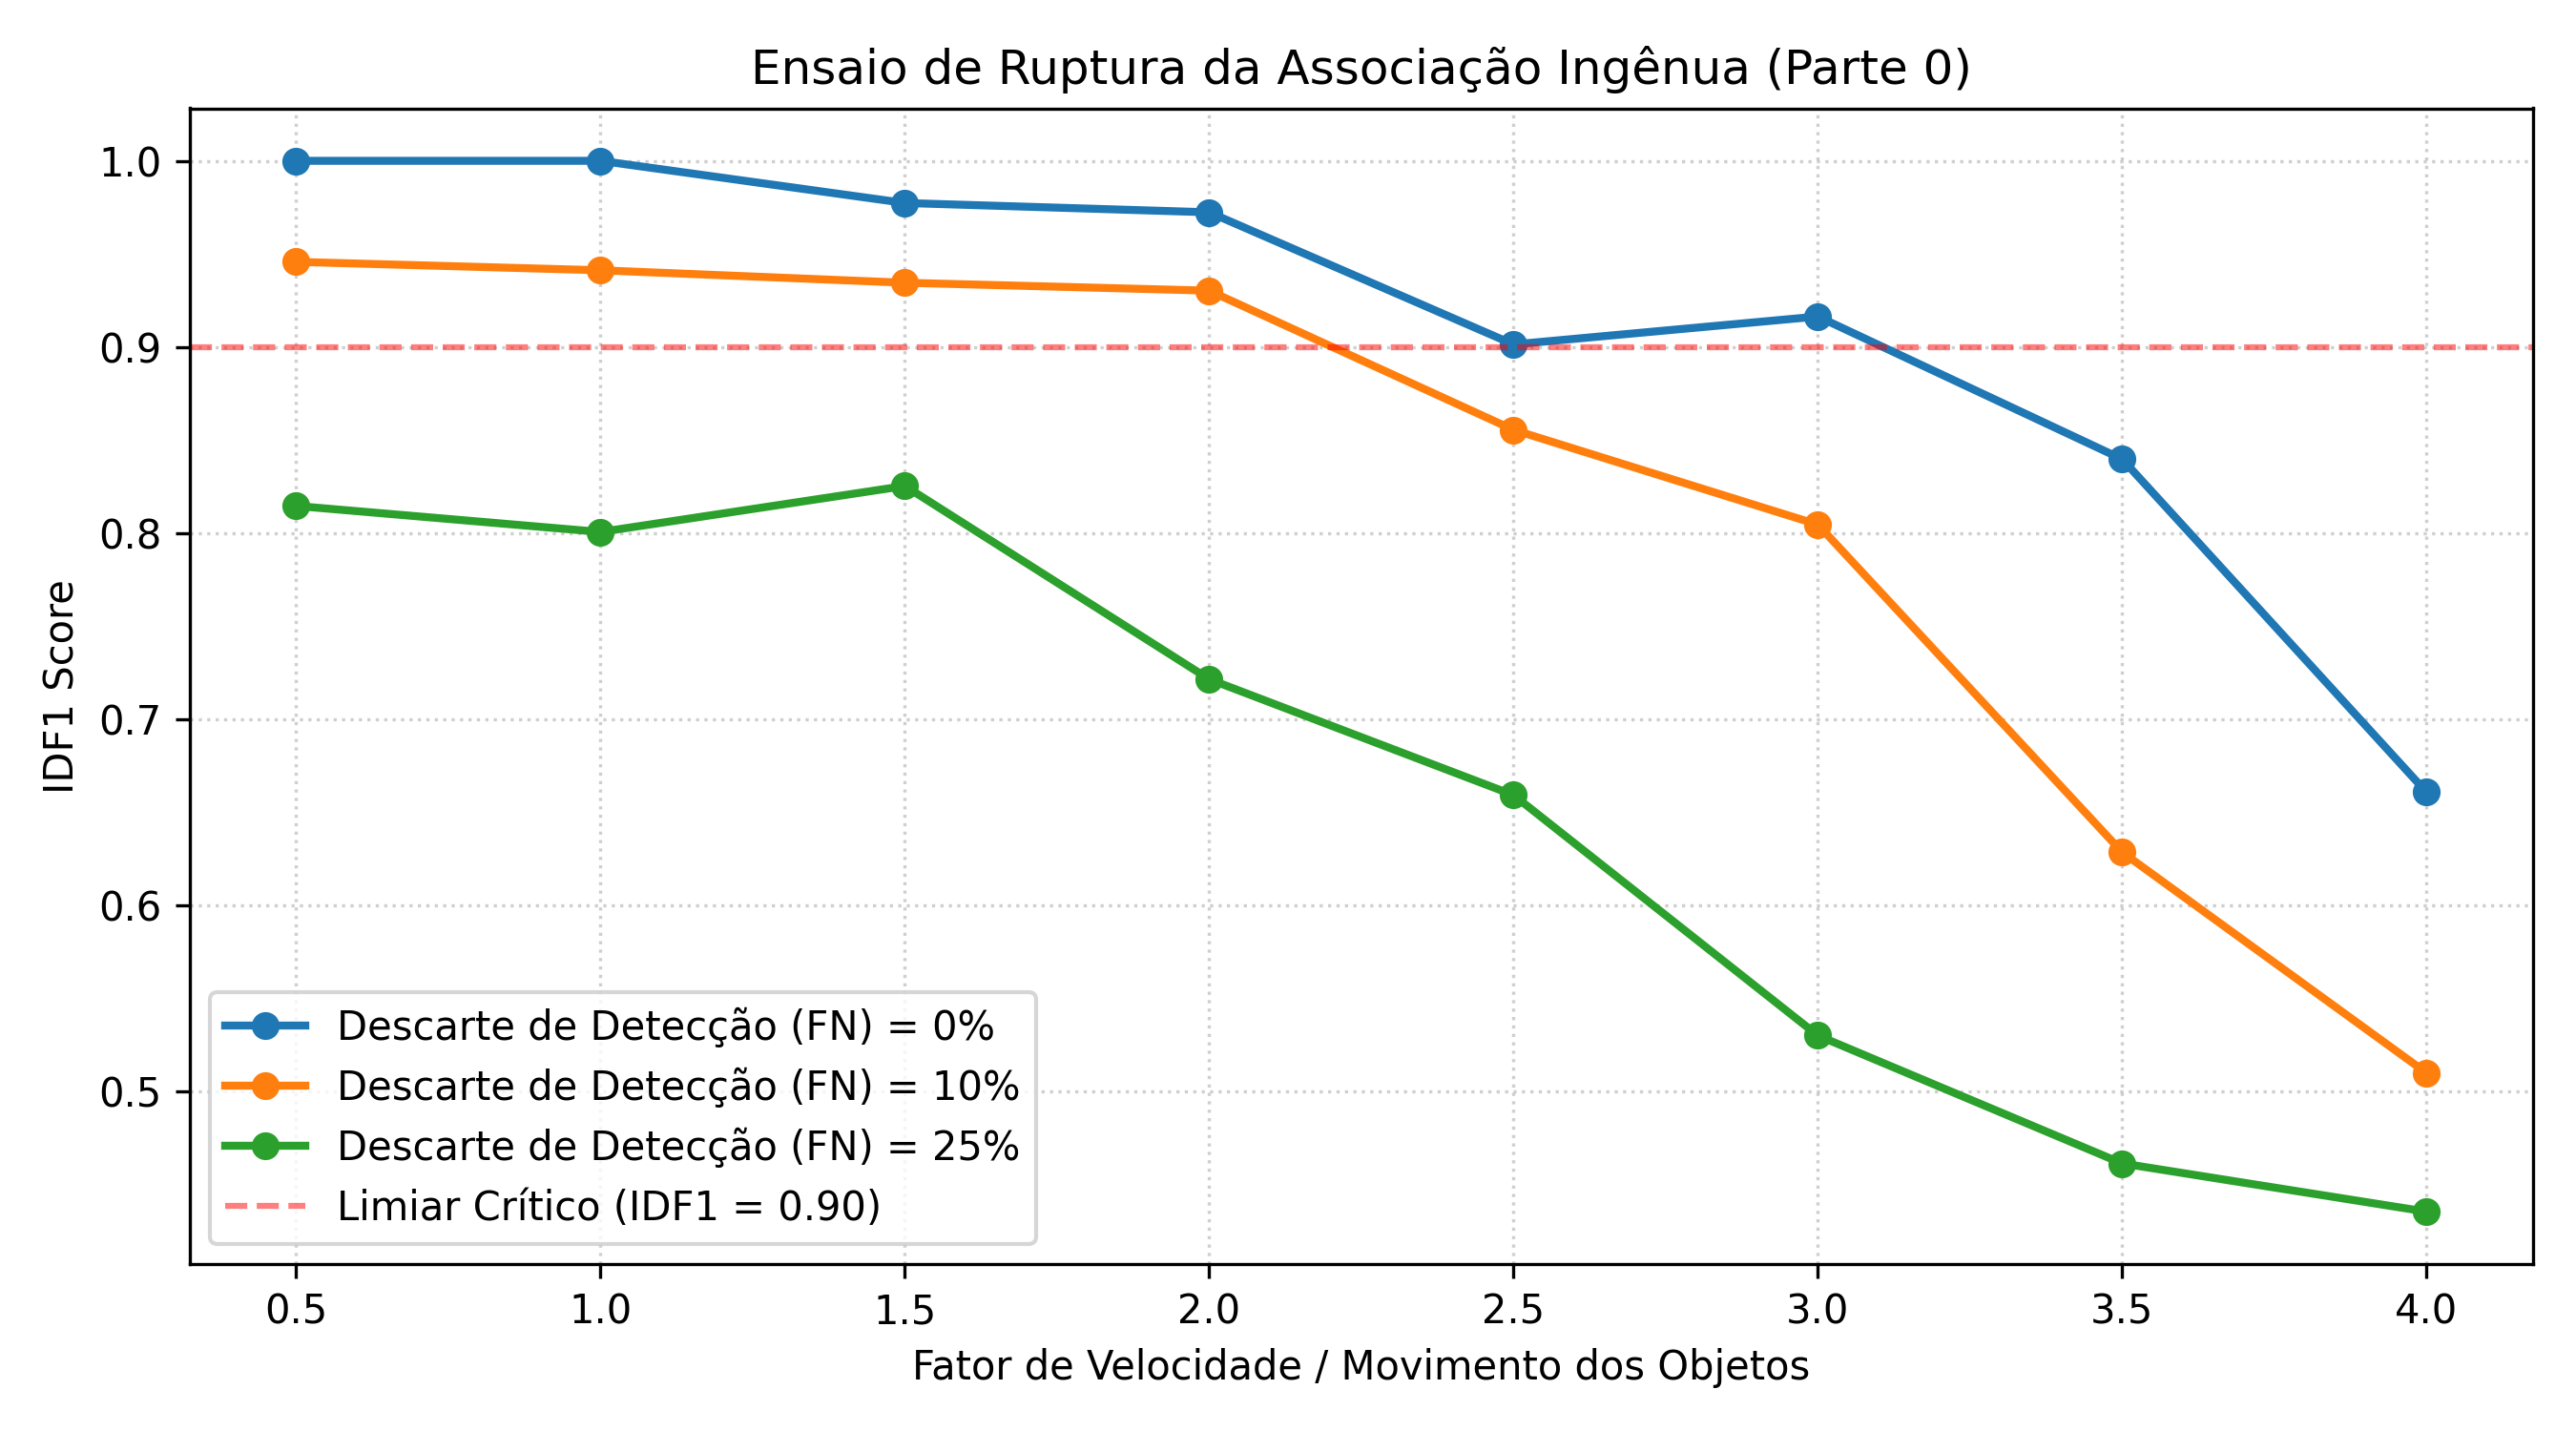

In [11]:
# Exibir a imagem gerada
from IPython.display import Image
image_path = 'outputs/synthetic_experiments/ruptura_parte0.png'
Image(filename=image_path)

In [8]:
# Roda a associação ingênua (frame a frame) nos dados do MOT17 que você baixou
!python experiment/part1_baseline.py

RESULTADOS DA PARTE 1 - Sequência: MOT17-02-SDP
mAP Médio Espacial: 0.4438
IDF1 Temporal:      0.3645
Identidades GT:     62 | Previstas: 462 (Razão: 7.45)
ID Switches Total:  434 (7.00 por identidade)
Gráfico do descolamento guardado em: /content/DL_PA2/outputs/part1_experiments/part1_descolamento.png


### Gráfico da Parte 1

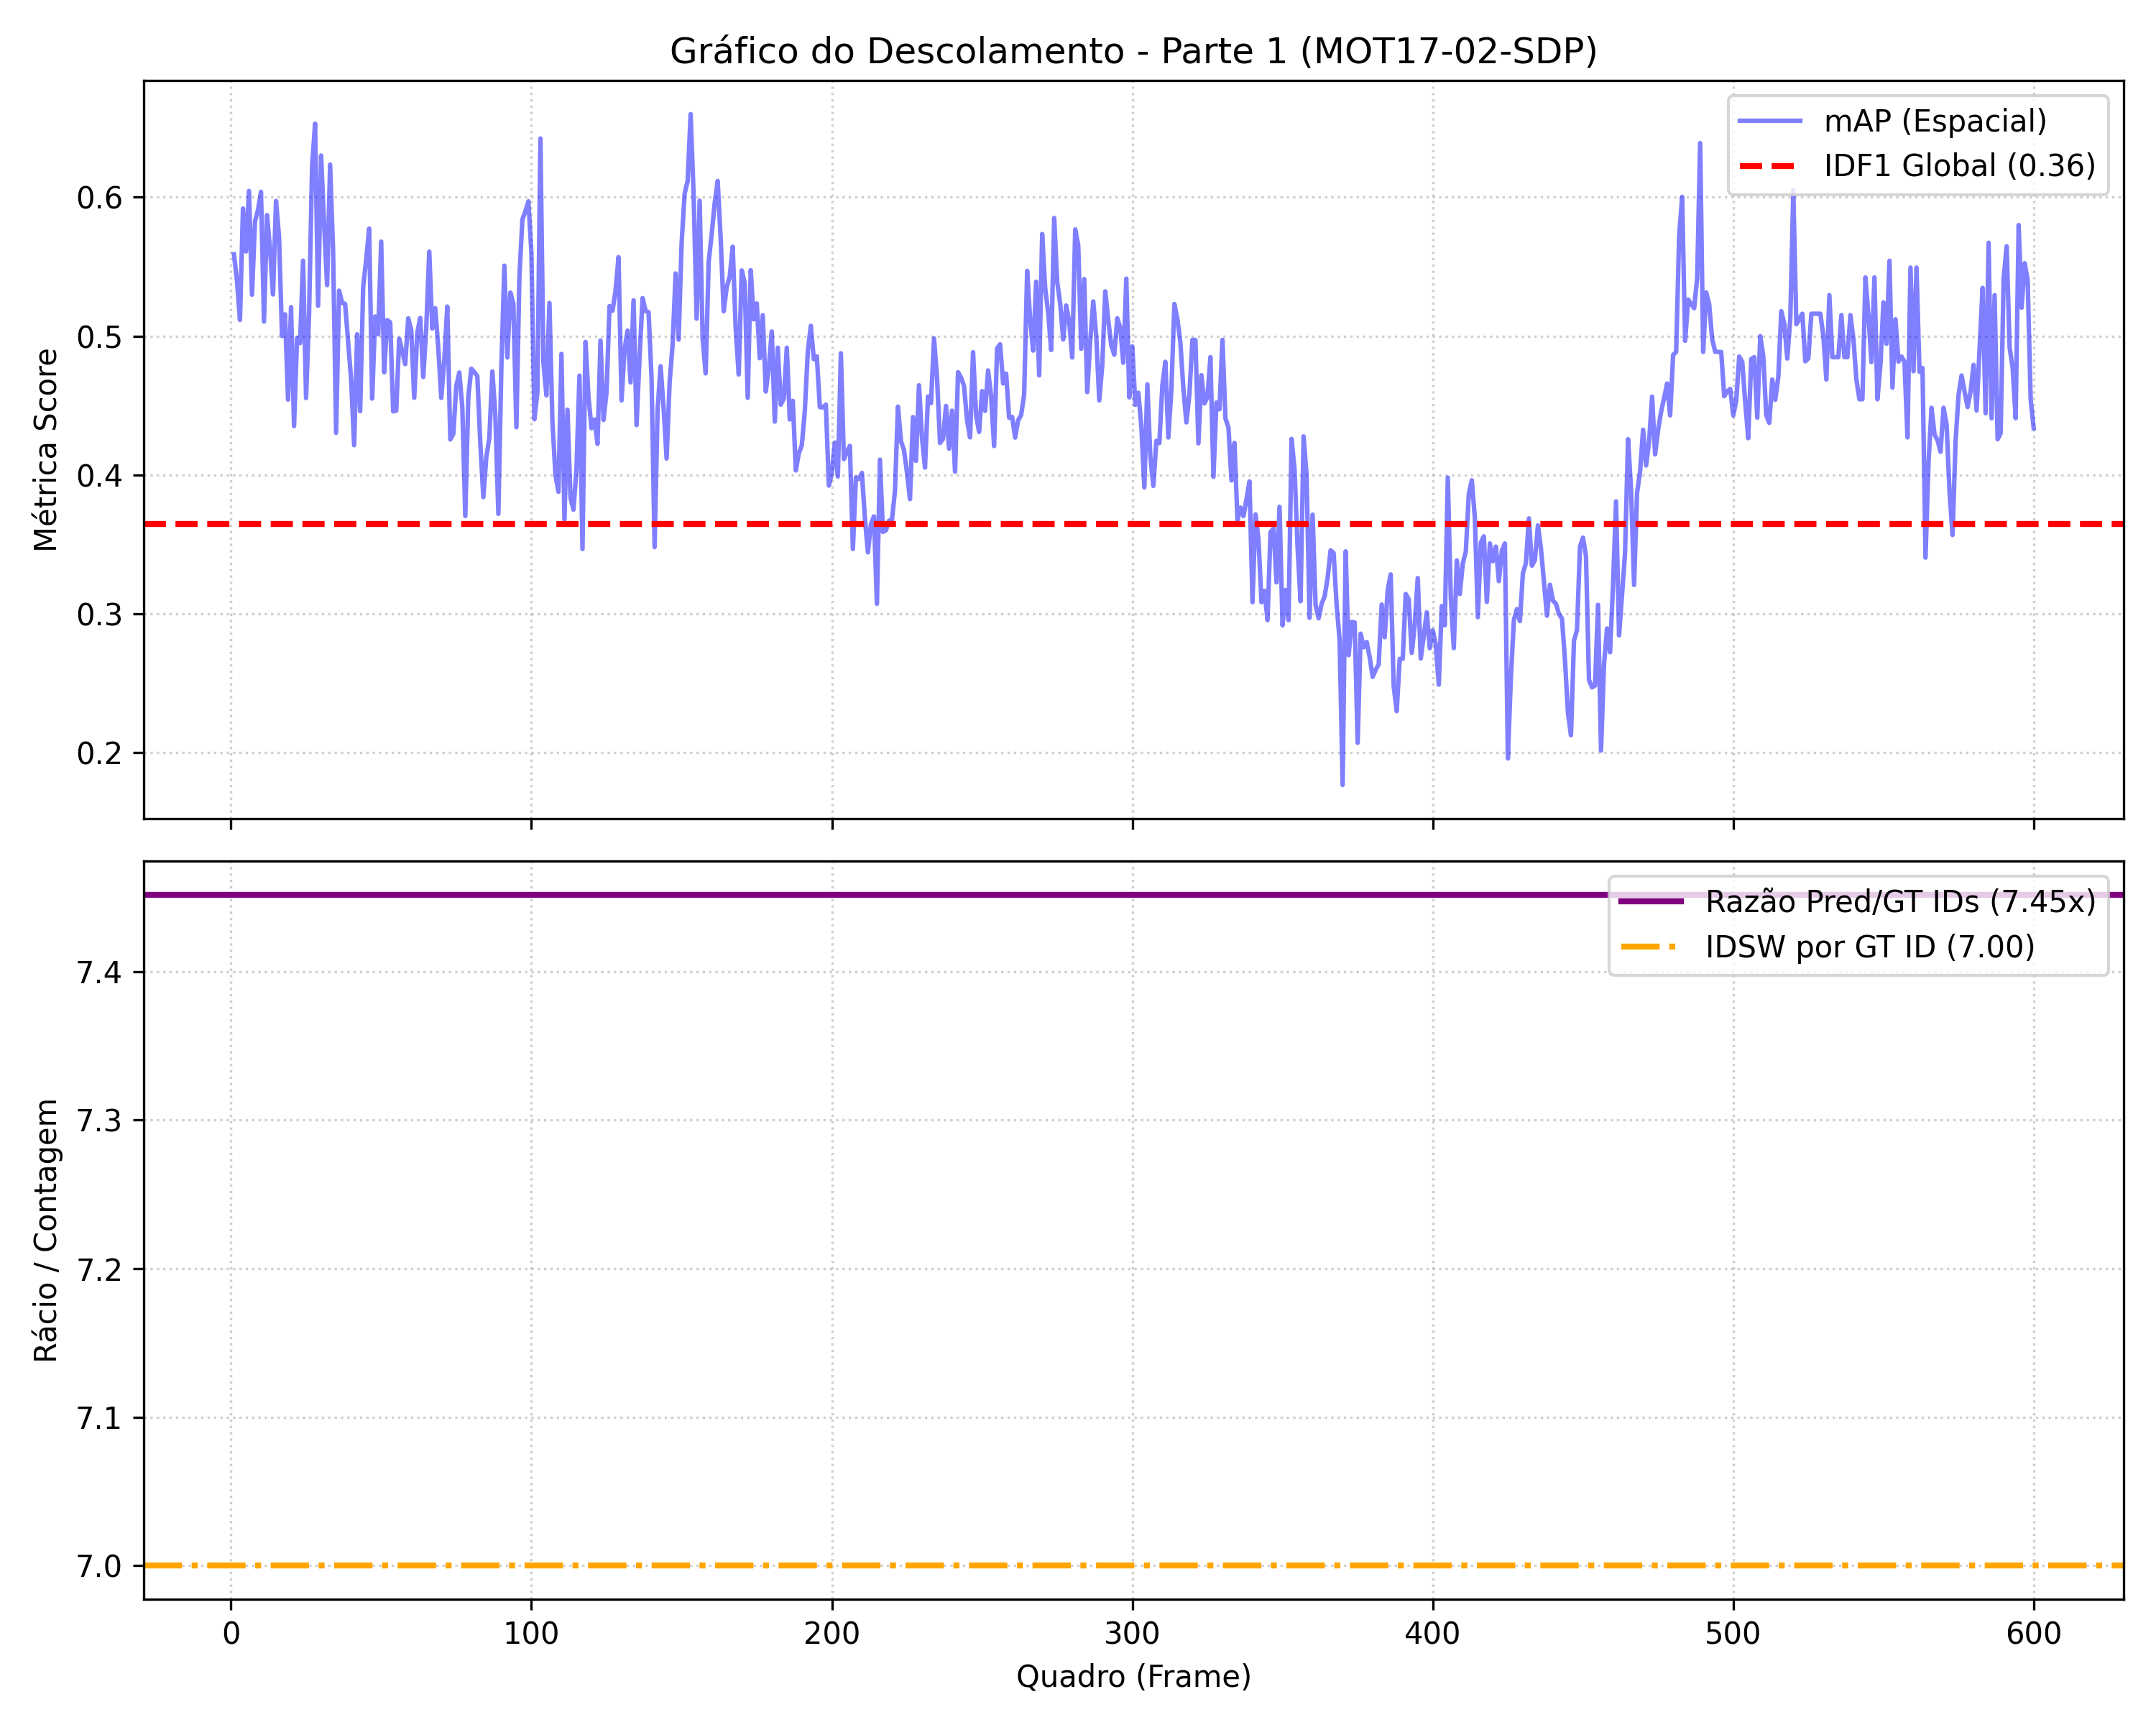

In [12]:
image_path_part1_descolamento = 'outputs/part1_experiments/part1_descolamento.png'
Image(filename=image_path_part1_descolamento)

## Parte 2

Treinar a RNN

In [14]:
!python experiment/train_part2.py

Iniciando treinamento no cuda com 17994 sequencias...
Epoca 01 | Perda Media: 0.007438
Epoca 02 | Perda Media: 0.000259
Epoca 03 | Perda Media: 0.000078
Epoca 04 | Perda Media: 0.000035
Epoca 05 | Perda Media: 0.000025
Epoca 06 | Perda Media: 0.000018
Epoca 07 | Perda Media: 0.000013
Epoca 08 | Perda Media: 0.000009
Epoca 09 | Perda Media: 0.000007
Epoca 10 | Perda Media: 0.000006
Epoca 11 | Perda Media: 0.000006
Epoca 12 | Perda Media: 0.000005
Epoca 13 | Perda Media: 0.000005
Epoca 14 | Perda Media: 0.000004
Epoca 15 | Perda Media: 0.000004
Epoca 16 | Perda Media: 0.000003
Epoca 17 | Perda Media: 0.000003
Epoca 18 | Perda Media: 0.000003
Epoca 19 | Perda Media: 0.000003
Epoca 20 | Perda Media: 0.000003
Pesos salvos em outputs/models/rnn_motion.pth!


Avaliar a RNN

In [15]:
!python experiment/part2_baseline.py

Iniciando inferência com RNN Tracker...
/content/DL_PA2/src/tracking/rnn_tracker.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_in = torch.tensor([[trk['last_box']]]) / 1000.0
RESULTADOS DA PARTE 2 - Trilha A (LSTM)
IDF1 Temporal:      0.3813
ID Switches Total:  436
Fragmentações:      595


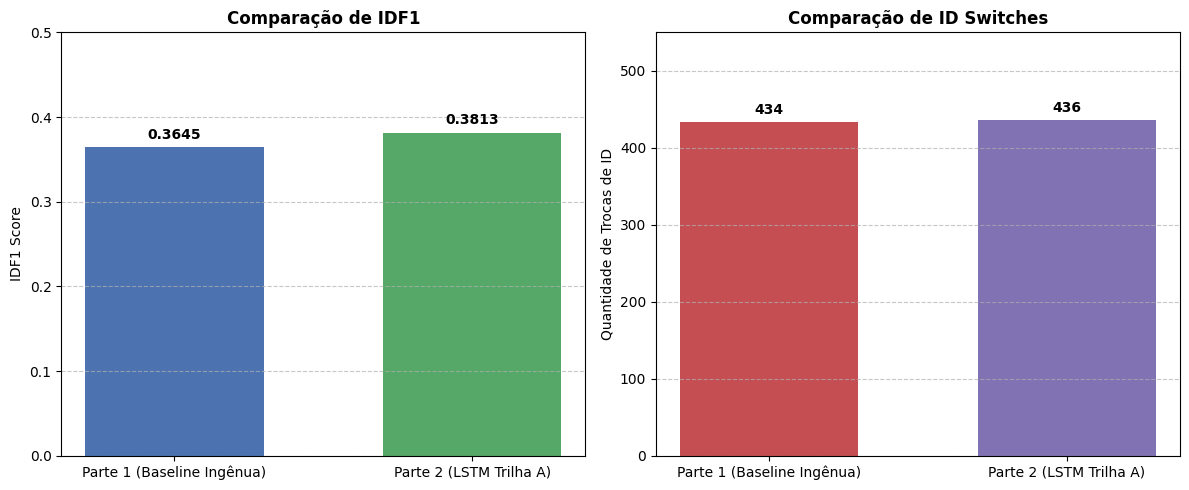

In [23]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('outputs/part2_experiments', exist_ok=True)

# Dados das duas partes (Coloquei manualmente os valores!!!)
labels = ['Parte 1 (Baseline Ingênua)', 'Parte 2 (LSTM Trilha A)']
idf1_scores = [0.3645, 0.3813]
idsw_counts = [434, 436]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Painel 1: IDF1 (Quanto maior, melhor)
bars1 = ax1.bar(labels, idf1_scores, color=['#4C72B0', '#55A868'], width=0.6)
ax1.set_title('Comparação de IDF1', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 0.5)
ax1.set_ylabel('IDF1 Score')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar valores no topo das barras
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold')

# Painel 2: ID Switches (Quanto menor, melhor)
bars2 = ax2.bar(labels, idsw_counts, color=['#C44E52', '#8172B3'], width=0.6)
ax2.set_title('Comparação de ID Switches', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 550)
ax2.set_ylabel('Quantidade de Trocas de ID')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{bar.get_height()}', ha='center', fontweight='bold')

plt.tight_layout()

caminho_salvamento = 'outputs/part2_experiments/comparacao_partes1_2.png'
plt.savefig(caminho_salvamento, dpi=300)
plt.show()

## Parte 3

In [26]:
# Roda as 36 combinações
!python experiment/part3_ablation.py


--- Iniciando configuração: Célula RNN | Janela BPTT 4 ---
/content/DL_PA2/src/tracking/ablation_tracker.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_in = torch.tensor([trk['last_box']]) / 1000.0
Seed 2026 -> IDF1: 0.2834
Seed 2027 -> IDF1: 0.3135
Seed 2028 -> IDF1: 0.2822

--- Iniciando configuração: Célula RNN | Janela BPTT 8 ---
Seed 2026 -> IDF1: 0.3644
Seed 2027 -> IDF1: 0.3520
Seed 2028 -> IDF1: 0.3275

--- Iniciando configuração: Célula RNN | Janela BPTT 16 ---
Seed 2026 -> IDF1: 0.2968
Seed 2027 -> IDF1: 0.3500
Seed 2028 -> IDF1: 0.2949

--- Iniciando configuração: Célula RNN | Janela BPTT 32 ---
Seed 2026 -> IDF1: 0.3156
Seed 2027 -> IDF1: 0.3351
Seed 2028 -> IDF1: 0.3767

--- Iniciando configuração: Célula GRU | Janela BPTT 4 ---
Seed 2026 -> IDF1: 

In [35]:
# Plota e exibe o gráfico
!python experiment/viz_part3.py

Gráfico Small Multiples salvo em: /content/DL_PA2/outputs/part3_experiments/grafico_ablacao_small_multiples.png


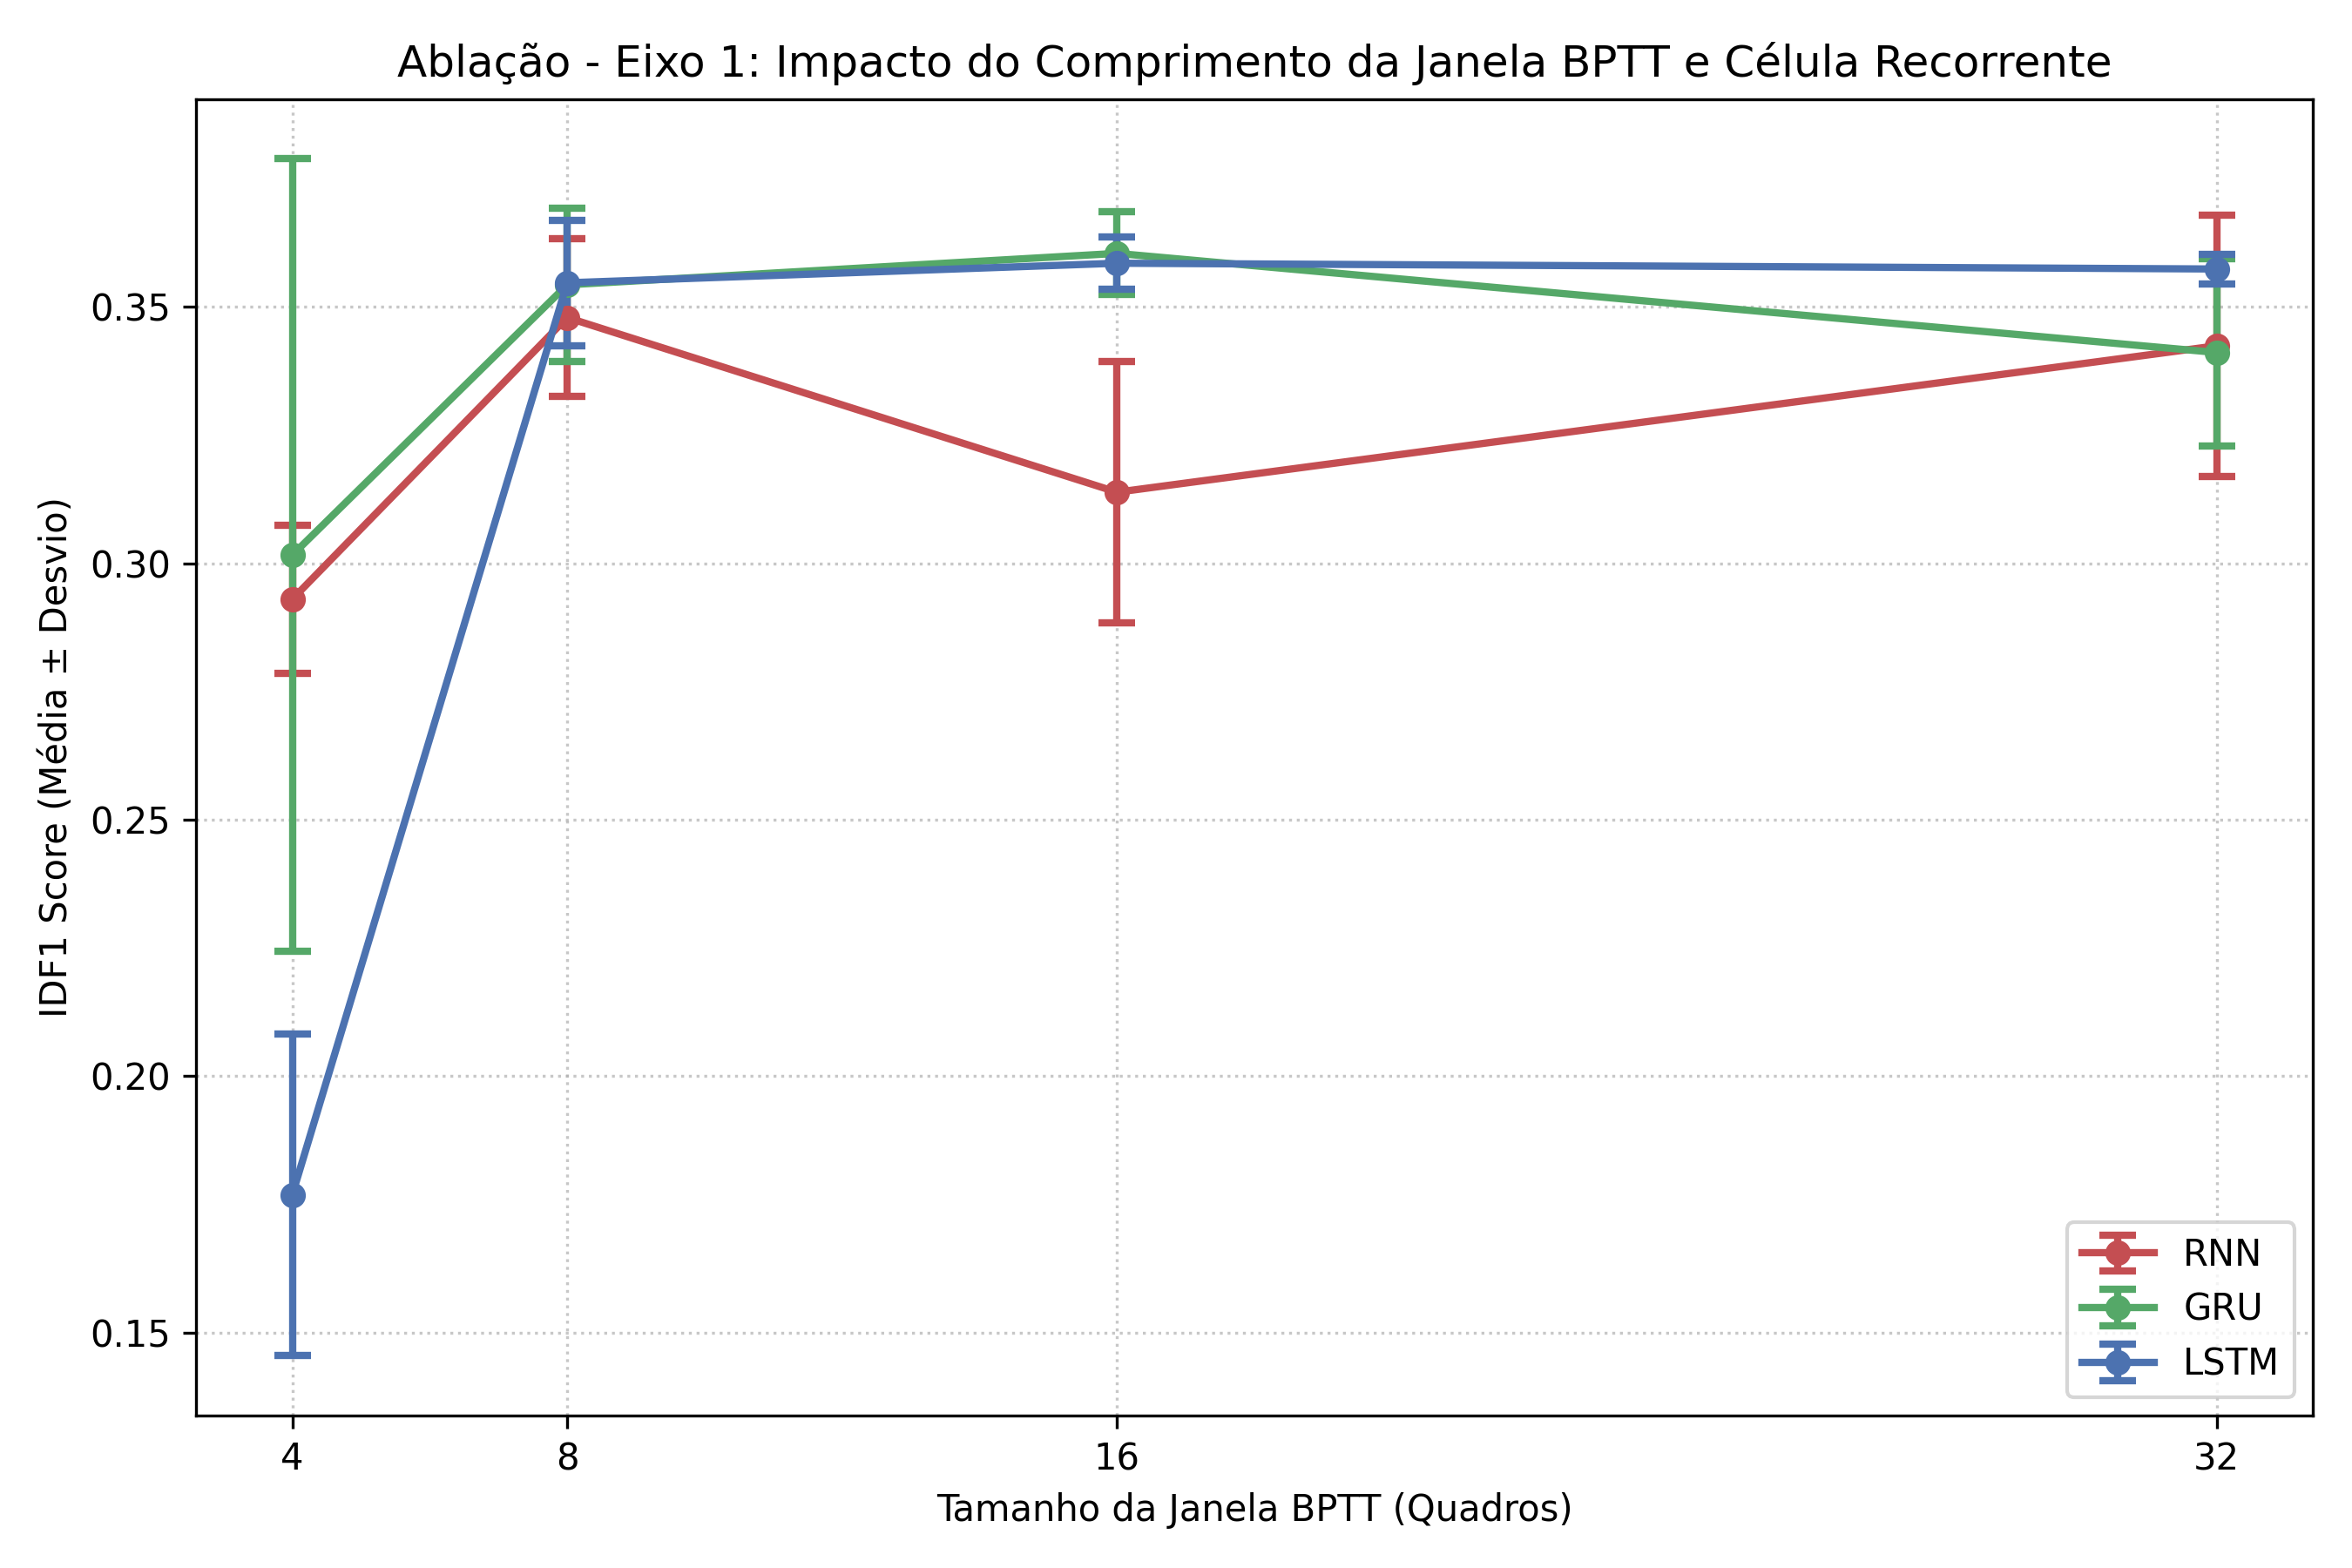

In [37]:
image_path_part3 = 'outputs/part3_experiments/grafico_ablacao.png'
Image(filename=image_path_part3)

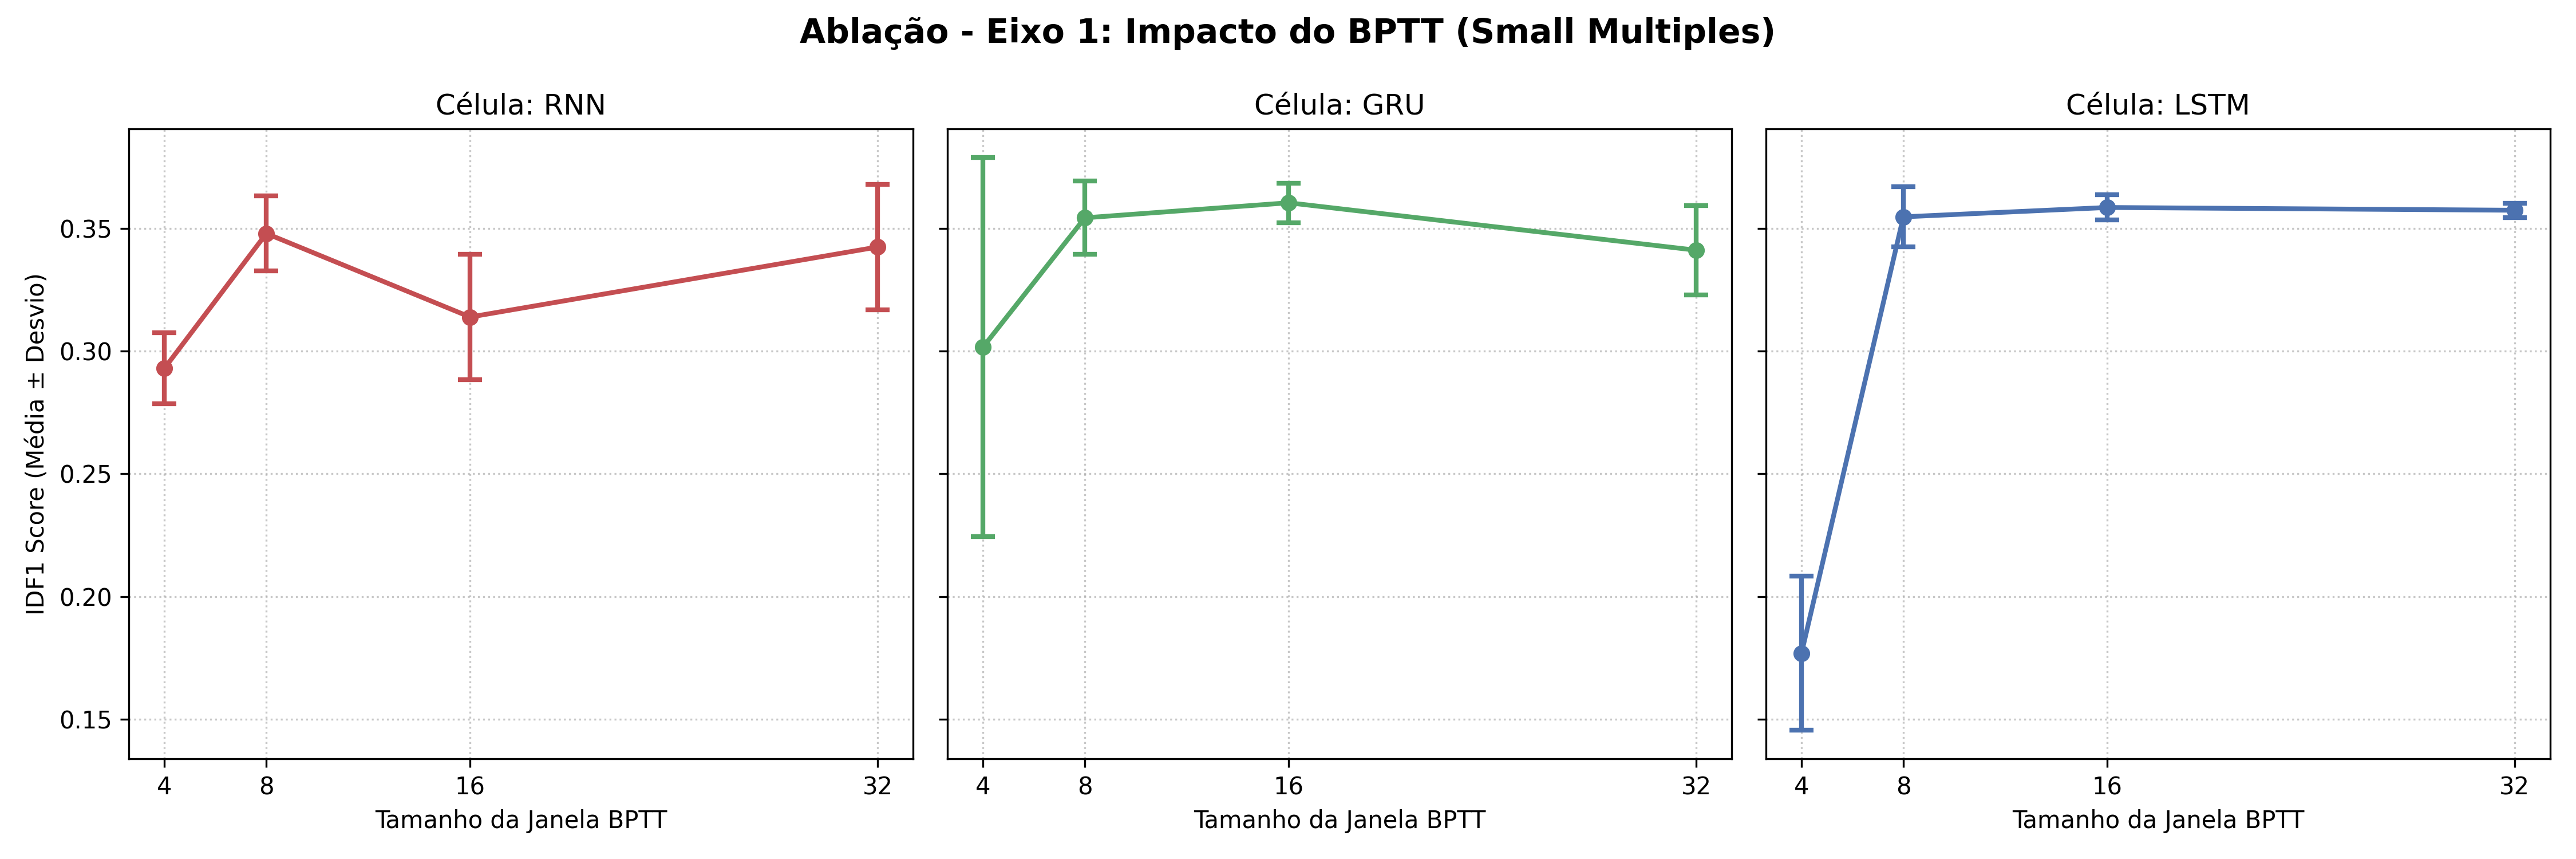

In [38]:
image_path_part3 = 'outputs/part3_experiments/grafico_ablacao_small_multiples.png'
Image(filename=image_path_part3)

## Parte 5

In [39]:
!python experiment/part5_stress.py

Iniciando Teste de Estresse do Detector...

Testando nível: Original
/content/DL_PA2/src/tracking/rnn_tracker.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_in = torch.tensor([[trk['last_box']]]) / 1000.0
-> mAP: 0.4436 | IDF1: 0.3811

Testando nível: Leve
-> mAP: 0.3591 | IDF1: 0.2474

Testando nível: Média
-> mAP: 0.1658 | IDF1: 0.1074

Testando nível: Severa
-> mAP: 0.0579 | IDF1: 0.0354

 Gráfico salvo em outputs/part5_experiments/estresse_detector.png


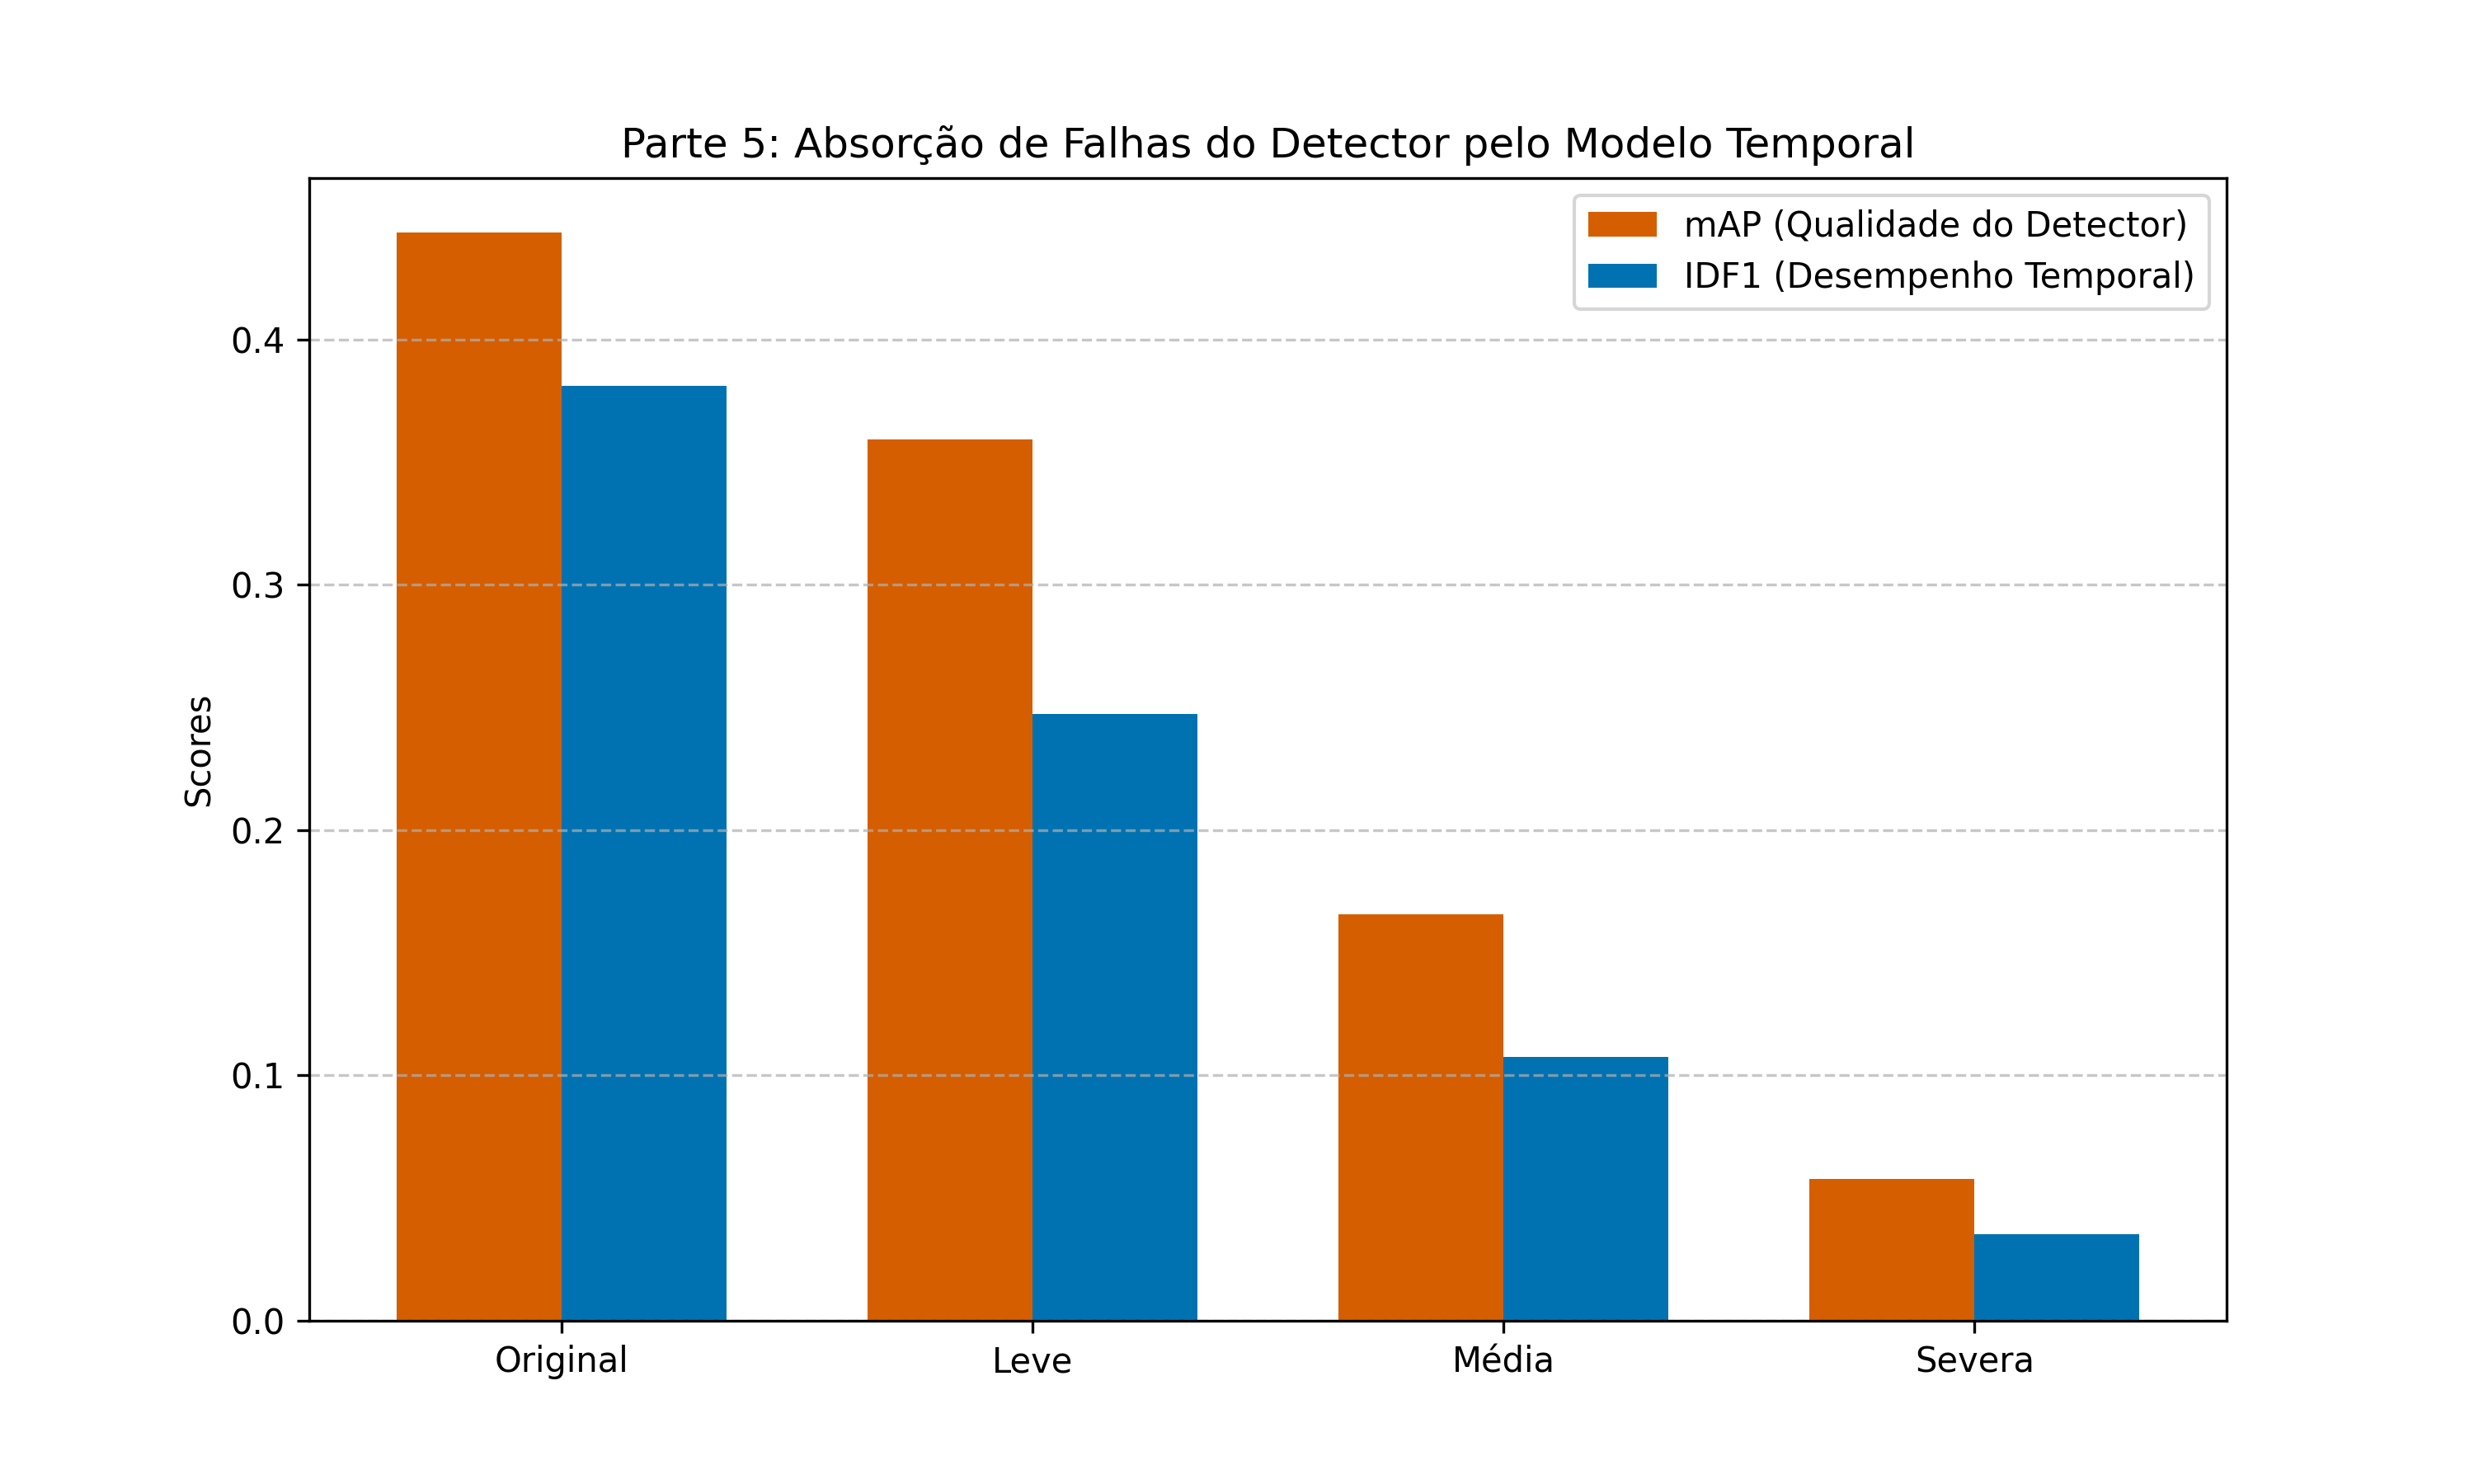

In [40]:
image_path_part5 = 'outputs/part5_experiments/estresse_detector.png'
Image(filename=image_path_part5)